In [1]:
from tensorflow.keras.applications import VGG16

cnn_model = VGG16(
    weights='imagenet',
    include_top=False
)
cnn_model.trainable = False

In [2]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

def preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return img

In [3]:
def extract_features(image_path):
    image = preprocess_image(image_path)
    features = cnn_model.predict(image, verbose=0)
    features = features.reshape(-1)  # flatten to (25088,)
    return features

In [4]:
import os
from tqdm import tqdm

path="C:\\Users\\SECHGUR\\OneDrive - ABB\\Documents\\Personal\\LTU\\Advanced deep learning\\Assignments\\Lab_3\\flickr8k"
image_folder = os.path.join(path, "images")
image_files = os.listdir(image_folder)

image_features = {}

for image_name in tqdm(image_files, desc="Extracting features"):
    image_path = os.path.join(image_folder, image_name)
    image_features[image_name] = extract_features(image_path)

Extracting features:   0%|          | 0/8091 [00:00<?, ?it/s]

Extracting features: 100%|██████████| 8091/8091 [22:37<00:00,  5.96it/s]


Image features were extracted using a pretrained VGG16 CNN with ImageNet weights. The fully connected layers were removed, and each image was represented as a 25,088‑dimensional feature vector. Features were extracted once and cached to disk to reduce computational cost during training.

In [5]:
import pickle

with open("flickr8k_image_features.pkl", "wb") as f:
    pickle.dump(image_features, f)

In [6]:
import pandas as pd

captions_path = os.path.join(path, "captions.txt")

df = pd.read_csv(captions_path)
df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [7]:
#basic caption cleaning function
import string

def clean_caption(caption):
    caption = caption.lower()
    caption = caption.translate(str.maketrans('', '', string.punctuation))
    caption = caption.strip()
    caption = " ".join(caption.split())
    caption = f"<start> {caption} <end>"
    return caption

In [8]:
#group captions by image
from collections import defaultdict

image_to_captions = defaultdict(list)

for _, row in df.iterrows():
    image = row["image"]
    caption = clean_caption(row["caption"])
    image_to_captions[image].append(caption)

In [9]:
set(image_to_captions.keys()) == set(image_features.keys())

True

In [10]:
missing = set(image_to_captions.keys()) - set(image_features.keys())
len(missing)

0

In [11]:
import random

image_ids = list(image_to_captions.keys())
len(image_ids)

8091

In [12]:
random.seed(42)
random.shuffle(image_ids)

train_ratio = 0.7
val_ratio = 0.15

total_images = len(image_ids)

train_end = int(total_images * train_ratio)
val_end = int(total_images * (train_ratio + val_ratio))

train_images = image_ids[:train_end]
val_images = image_ids[train_end:val_end]
test_images = image_ids[val_end:]

In [13]:
print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

Train images: 5663
Validation images: 1214
Test images: 1214


In [14]:
assert set(train_images).isdisjoint(val_images)
assert set(train_images).isdisjoint(test_images)
assert set(val_images).isdisjoint(test_images)

print("No image leakage across splits")

No image leakage across splits


In [15]:
#split specific caption dictionaries
train_captions = {img: image_to_captions[img] for img in train_images}
val_captions   = {img: image_to_captions[img] for img in val_images}
test_captions  = {img: image_to_captions[img] for img in test_images}

#image features with each split
train_features = {img: image_features[img] for img in train_images}
val_features   = {img: image_features[img] for img in val_images}
test_features  = {img: image_features[img] for img in test_images}

The Flickr8k dataset was split at the image level into training (70%), validation (15%), and testing (15%) subsets. All captions belonging to a single image were kept within the same split to prevent information leakage.

In [16]:
all_train_captions = []

for captions in train_captions.values():
    all_train_captions.extend(captions)

len(all_train_captions)

28315

In [17]:
#create and fit the tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer

max_vocab_size = 5000   # 4000–6000 works well for Flickr8k

tokenizer = Tokenizer(
    num_words=max_vocab_size,
    oov_token="<unk>"
)
tokenizer.fit_on_texts(all_train_captions)

In [18]:
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary size:", vocab_size)

Vocabulary size: 7532


In [19]:
#maximum caption length
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = max(len(caption.split()) for caption in all_train_captions)
print("Max caption length:", max_length)

Max caption length: 38


In [20]:
#sequence generation function
import numpy as np
from tensorflow.keras.utils import to_categorical

def create_sequences_sparse(tokenizer, max_length, captions, image_feature):
    X_img, X_seq, y = [], [], []

    for caption in captions:
        seq = tokenizer.texts_to_sequences([caption])[0]

        for i in range(1, len(seq)):
            in_seq = seq[:i]
            out_word = seq[i] 

            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]

            X_img.append(image_feature)
            X_seq.append(in_seq)
            y.append(out_word)

    return np.array(X_img), np.array(X_seq), np.array(y)

A tokenizer is trained exclusively on the training captions to prevent information leakage. Captions were converted into sequences, and for each image–caption pair multiple training samples were generated using a next‑word prediction strategy.

In [21]:
X_img_train, X_seq_train, y_train = [], [], []

for img in train_images:
    img_feature = train_features[img]
    captions = train_captions[img]

    X1, X2, y = create_sequences_sparse(
        tokenizer,
        max_length,
        captions,
        img_feature
    )

    X_img_train.extend(X1)
    X_seq_train.extend(X2)
    y_train.extend(y)
    
#convert to numpy arrays
X_img_train = np.array(X_img_train)
X_seq_train = np.array(X_seq_train)
y_train = np.array(y_train)

In [22]:
print("Image features shape:", X_img_train.shape)
print("Caption sequences shape:", X_seq_train.shape)
print("Output words shape:", y_train.shape)

Image features shape: (333436, 25088)
Caption sequences shape: (333436, 38)
Output words shape: (333436,)


In [23]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Embedding, LSTM, Dropout, Concatenate
)
from tensorflow.keras.optimizers import Adam

In [24]:
#image feature branch
image_input = Input(shape=(25088,), name="image_input")
image_dense = Dense(256, activation="relu")(image_input)
image_dense = Dropout(0.5)(image_dense)

In [25]:
#caption branch
caption_input = Input(shape=(max_length,), name="caption_input")

caption_embedding = Embedding(
    input_dim=vocab_size,
    output_dim=256,
    mask_zero=True
)(caption_input)

caption_lstm = LSTM(256)(caption_embedding)

In [26]:
#combine image + text (concatenation)
combined = Concatenate()([image_dense, caption_lstm])
combined = Dense(256, activation="relu")(combined)
combined = Dropout(0.5)(combined)

In [27]:
#output layer
output = Dense(vocab_size, activation="softmax")(combined)

#build the model
model = Model(
    inputs=[image_input, caption_input],
    outputs=output
)

In [28]:
#compile the model
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 25088)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  6,422,784 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  1,928,192 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 38)        │          0 │ caption_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 7532)      │  1,935,724 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,943,340 (41.75 MB)

 Trainable params: 10,943,340 (41.75 MB)

 Non-trainable params: 0 (0.00 B)

The implemented model contains two input branches: one for CNN‑extracted image features and one for caption sequences processed by an embedding layer and LSTM. The embeddings are concatenated and passed through fully connected layers to predict the next word in the caption.

In [29]:
#generate validation data
X_img_val, X_seq_val, y_val = [], [], []

for img in val_images:
    img_feature = val_features[img]
    captions = val_captions[img]

    X1, X2, y = create_sequences_sparse(
        tokenizer, max_length, captions, img_feature
    )

    X_img_val.extend(X1)
    X_seq_val.extend(X2)
    y_val.extend(y)

X_img_val = np.array(X_img_val)
X_seq_val = np.array(X_seq_val)
y_val = np.array(y_val)

In [30]:
print(X_img_val.shape)
print(X_seq_val.shape)
print(y_val.shape)

(71509, 25088)
(71509, 38)
(71509,)


In [31]:
def data_generator(images, captions_dict, features_dict,
                   tokenizer, max_length, batch_size=64):
    while True:
        X_img, X_seq, y = [], [], []

        for img in images:
            img_feature = features_dict[img]
            captions = captions_dict[img]

            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):
                    in_seq = seq[:i]
                    out_word = seq[i]

                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]

                    X_img.append(img_feature)
                    X_seq.append(in_seq)
                    y.append(out_word)

                    if len(X_img) == batch_size:
                        yield (
                            (np.array(X_img), np.array(X_seq)),
                            np.array(y)
                        )
                        X_img, X_seq, y = [], [], []

In [32]:
steps_per_epoch = len(train_images) * 5 // 64
val_steps = len(val_images) * 5 // 64

history = model.fit(
    data_generator(
        train_images, train_captions, train_features,
        tokenizer, max_length
    ),
    validation_data=data_generator(
        val_images, val_captions, val_features,
        tokenizer, max_length
    ),
    epochs=10,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps
)

Epoch 1/10
442/442 ━━━━━━━━━━━━━━━━━━━━ 48s 104ms/step - accuracy: 0.1634 - loss: 5.7872 - val_accuracy: 0.2400 - val_loss: 4.8993
Epoch 2/10
442/442 ━━━━━━━━━━━━━━━━━━━━ 44s 100ms/step - accuracy: 0.2372 - loss: 4.9278 - val_accuracy: 0.2380 - val_loss: 4.5191
Epoch 3/10
442/442 ━━━━━━━━━━━━━━━━━━━━ 43s 97ms/step - accuracy: 0.2463 - loss: 4.6992 - val_accuracy: 0.2643 - val_loss: 4.3590
Epoch 4/10
442/442 ━━━━━━━━━━━━━━━━━━━━ 46s 103ms/step - accuracy: 0.2587 - loss: 4.4975 - val_accuracy: 0.2836 - val_loss: 4.1867
Epoch 5/10
442/442 ━━━━━━━━━━━━━━━━━━━━ 61s 138ms/step - accuracy: 0.2707 - loss: 4.3850 - val_accuracy: 0.2713 - val_loss: 4.1079
Epoch 6/10
442/442 ━━━━━━━━━━━━━━━━━━━━ 42s 95ms/step - accuracy: 0.2799 - loss: 4.3459 - val_accuracy: 0.2832 - val_loss: 4.0734
Epoch 7/10
442/442 ━━━━━━━━━━━━━━━━━━━━ 43s 97ms/step - accuracy: 0.2865 - loss: 4.3141 - val_accuracy: 0.2877 - val_loss: 3.9702
Epoch 8/10
442/442 ━━━━━━━━━━━━━━━━━━━━ 58s 130ms/step - accuracy: 0.2890 - loss: 4.35

The model was trained for 10 epochs using a generator‑based strategy with sparse categorical cross‑entropy. Validation loss was computed at the end of each epoch and showed steady convergence without significant overfitting.

In [33]:
index_to_word = {index: word for word, index in tokenizer.word_index.items()}

In [34]:
#caption generation function
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def generate_caption(model, image_feature, tokenizer, max_length):
    caption = "<start>"

    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([caption])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)

        y_pred = model.predict([image_feature.reshape(1, -1), sequence], verbose=0)
        predicted_word_index = np.argmax(y_pred)

        word = index_to_word.get(predicted_word_index, None)

        if word is None:
            break

        caption += " " + word

        if word == "<end>" or word == "end":
            break

    return caption

In [35]:
#generate captions for test images
sample_test_images = list(test_features.keys())[:5]

for img in sample_test_images:
    feature = test_features[img]
    generated_caption = generate_caption(model, feature, tokenizer, max_length)

    print(f"Image: {img}")
    print("Generated Caption:", generated_caption)
    print("Ground Truth Captions:")
    for cap in test_captions[img]:
        print(" -", cap)
    print("-" * 60)

Image: 2089542487_b4c1ee7025.jpg
Generated Caption: <start> a man in a red shirt is running on a beach end
Ground Truth Captions:
 - <start> a hiker is ready to take on a rugged outdoor trail <end>
 - <start> a lone hiker on a dirt hiking trail with a hat and sunglasses on with trees in the background <end>
 - <start> a man in shorts is hiking in a dry region <end>
 - <start> a man stops for a picture with the scenery during his hike <end>
 - <start> the man is posing for a picture in the desert wearing a green shirt and hat and holding a metal detector <end>
------------------------------------------------------------
Image: 2477121456_1ac5c6d3e4.jpg
Generated Caption: <start> a man in a red shirt is running on a beach end
Ground Truth Captions:
 - <start> a black dog plays in the water <end>
 - <start> a black dog s head rises above some water <end>
 - <start> a black dog splashes in the water <end>
 - <start> drenched black labrador in the water <end>
 - <start> the black dog s head

In [36]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SECHGUR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [37]:
#clean captions for BLEU
def clean_caption_for_bleu(caption):
    caption = caption.replace("<start>", "").replace("<end>", "")
    caption = caption.replace("end", "")
    caption = caption.strip()
    return caption.split()

In [38]:
#generate predictions on test images
references = []
hypotheses = []

smoothie = SmoothingFunction().method4

for img in test_images:
    # Generate caption
    feature = test_features[img]
    generated = generate_caption(model, feature, tokenizer, max_length)

    # Prepare ground truth captions
    gt_captions = test_captions[img]
    gt_tokens = [clean_caption_for_bleu(cap) for cap in gt_captions]

    # Prepare generated caption
    gen_tokens = clean_caption_for_bleu(generated)

    references.append(gt_tokens)
    hypotheses.append(gen_tokens)

In [39]:
#BLEU‑1 (Unigram)
bleu_1 = corpus_bleu(
    references,
    hypotheses,
    weights=(1.0, 0, 0, 0),
    smoothing_function=smoothie
)

In [40]:
#BLEU‑4 (Up to 4‑grams)
bleu_4 = corpus_bleu(
    references,
    hypotheses,
    weights=(0.25, 0.25, 0.25, 0.25),
    smoothing_function=smoothie
)


In [41]:
print(f"BLEU-1 score: {bleu_1:.4f}")
print(f"BLEU-4 score: {bleu_4:.4f}")

BLEU-1 score: 0.4774
BLEU-4 score: 0.0775


The trained image‑captioning model was evaluated on the unseen test set using BLEU scores. The model achieved a BLEU‑1 score of 0.4774 and a BLEU‑4 score of 0.0775. These results are consistent with baseline CNN–LSTM image captioning models on the Flickr8k dataset and indicate that the model successfully captures both object‑level and partial phrase‑level information despite the absence of an attention mechanism.

In [42]:
import matplotlib.pyplot as plt
from PIL import Image
import os

In [43]:
#caption cleaning for display
def clean_caption_display(caption):
    caption = caption.replace("<start>", "")
    caption = caption.replace("<end>", "")
    caption = caption.replace("end", "")
    return caption.strip()

In [44]:
def visualize_caption(image_name, image_path,
                      model, tokenizer, max_length,
                      test_features, test_captions):
    # Load image
    img = Image.open(os.path.join(image_path, image_name))

    # Generate caption
    feature = test_features[image_name]
    generated = generate_caption(model, feature, tokenizer, max_length)
    generated = clean_caption_display(generated)

    # Prepare ground truth
    gt_captions = [
        clean_caption_display(cap)
        for cap in test_captions[image_name]
    ]

    # Plot
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")

    title_text = "Generated Caption:\n"
    title_text += generated + "\n\nGround Truth Captions:\n"
    for cap in gt_captions:
        title_text += "- " + cap + "\n"

    plt.title(title_text, fontsize=10, loc="left")
    plt.show()

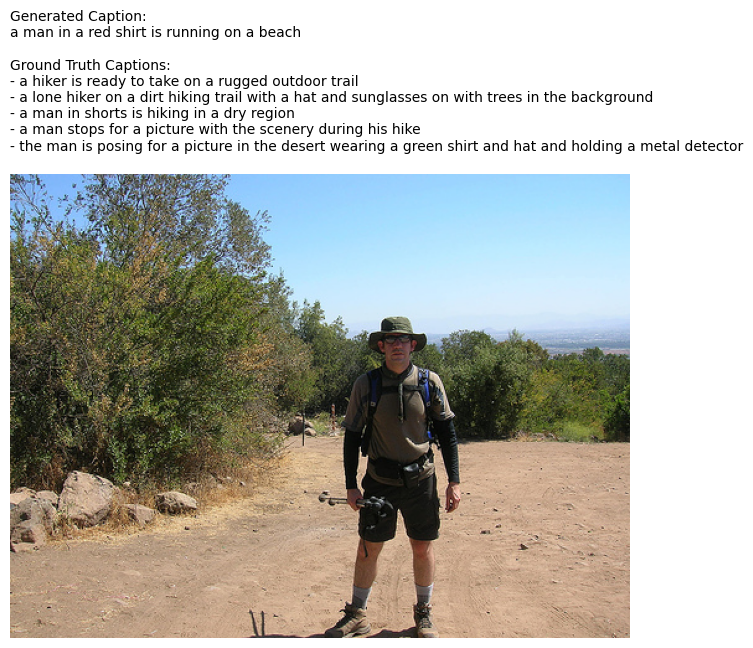

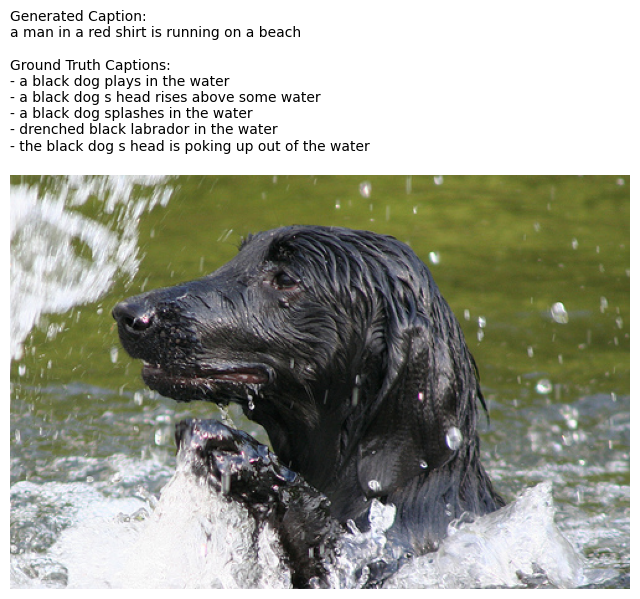

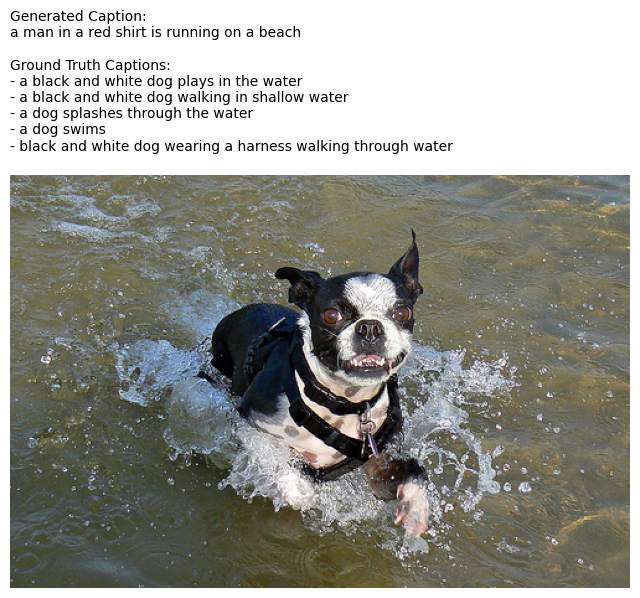

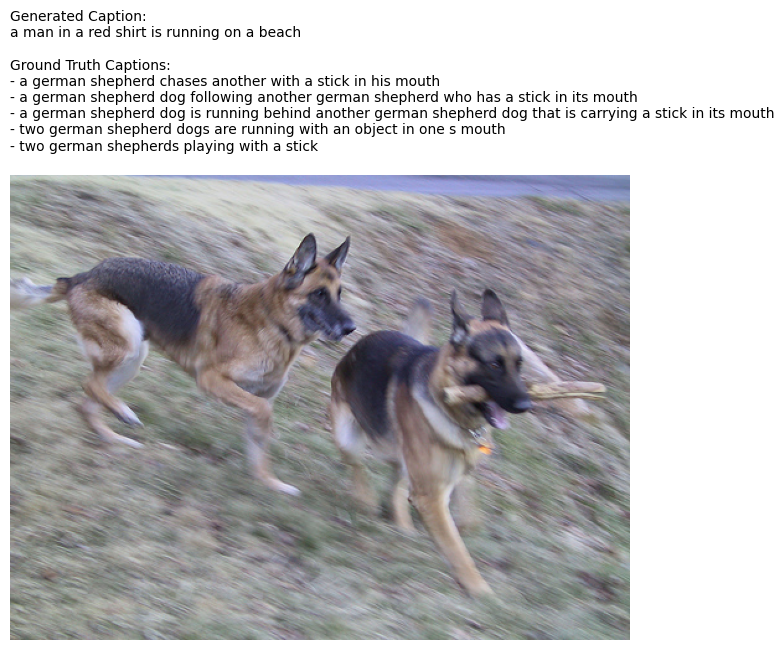

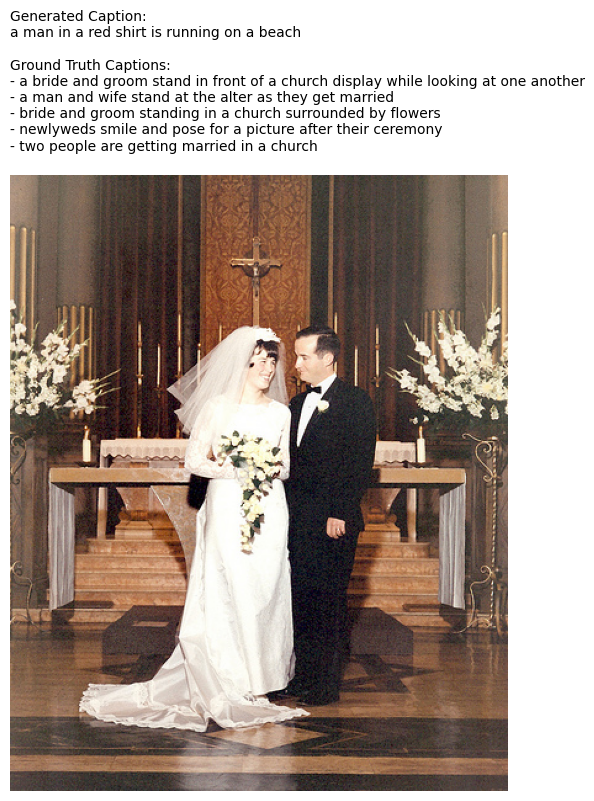

In [45]:
image_path = os.path.join(path, "images")

sample_images = test_images[:5]

for img_name in sample_images:
    visualize_caption(
        img_name,
        image_path,
        model,
        tokenizer,
        max_length,
        test_features,
        test_captions
    )